<a href="https://colab.research.google.com/github/ezekielchristianalcantara-pixel/ALCANTARA_Execise1/blob/main/ALCANTARA_Execise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## B. Load and understand the dataset

In [4]:
data = pd.read_excel("/personality_dataset.xlsx")

Display the first 5 rows of the dataset using `.head()`

In [5]:
data.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert


Display the summary of all the features of the dataset using `.info()`

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


Display the total number of samples from each label using `.value_counts()`

In [7]:
data["Personality"].value_counts()

,count
Personality,
Introvert,2502
Extrovert,2498


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

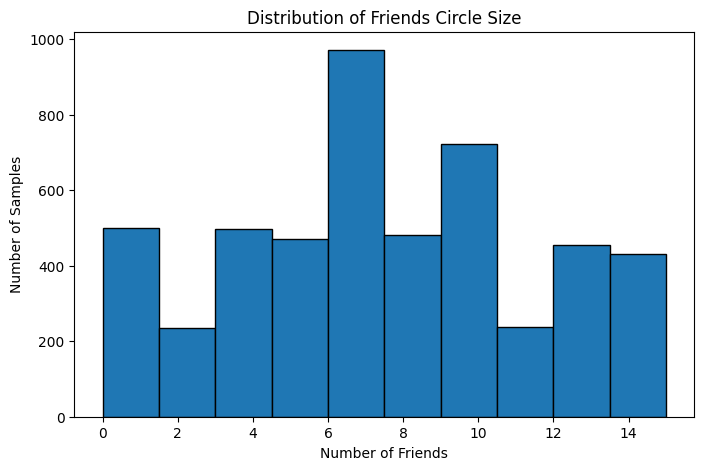

In [8]:
plt.figure(figsize=(8,5))
plt.hist(data['Friends_circle_size'], bins=10, edgecolor='black')
plt.title('Distribution of Friends Circle Size')
plt.xlabel('Number of Friends')
plt.ylabel('Number of Samples')
plt.show()

Remove the name column using `drop()` method

In [9]:
# put your answer here

## C. Split the dataset into training and test set

In [10]:
data['Stage_fear'] = data['Stage_fear'].map({'Yes': 1, 'No': 0})

data['Drained_after_socializing'] = data['Drained_after_socializing'].map({'Yes': 1, 'No': 0})

data['Personality'] = data['Personality'].map({
    'Introvert': 0,
    'Extrovert': 1
})

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [11]:
X = data.drop('Personality', axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [12]:
y = data['Personality'].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Display the dimensions of each variables using `.shape()`

In [14]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 7)
X_test shape: (1000, 7)
y_train shape: (4000,)
y_test shape: (1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [16]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [17]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


Create a confusion matrix

In [19]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[493   3]
 [  2 502]]


Display the accuracy

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.995


Display the precision

In [21]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.994059405940594


Display the recall

In [22]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.996031746031746


Display the f1-score

In [23]:
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

F1-score: 0.9950445986124876


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [24]:
my_features = np.array([[5, 0, 3, 4, 1, 10, 5]])

prediction = knn.predict(my_features)

if prediction[0] == 0:
    print("Your predicted personality is: Introvert")
else:
    print("Your predicted personality is: Extrovert")


Your predicted personality is: Introvert
